# V0 Variants Comparison

Ablation study comparing V0 baseline with incremental prompt additions.

## Prompt Components

- **V0 (baseline)**: Minimal zero-shot prompt — only the definition of Visual Complexity (0–1 scale). Model returns a single `vc_score` plus a brief explanation.
- **T (Topics, i.e. 7 complexity dimensions)**: Adds 7 dimensions (data density, visual encoding, semantics/text, schema, color/symbol, aesthetics, cognitive load) as mental checkpoints. Model still produces a single holistic `vc_score` — no per-dimension scores required. *(Named "topics" in the prompt; not to be confused with topic modeling elsewhere in the project.)*
- **C (Calibration)**: Adds scale anchoring guidance with example chart types mapped to approximate score ranges (plain bar chart ≈ 0.25–0.40, standard scatterplot ≈ 0.45–0.60, dense multi-panel ≈ 0.85–0.95). Instructs the model to use the full range and push scores up when uncertain. *(Note: the guidance only covers 0.25–0.95; the 0.0–0.25 region is left undefined.)*
- **A (Anchors)**: Prepends 3 labeled example images (vc_score = 0.22, 0.54, 0.95) as few-shot in-context references before the target image. Same minimal system prompt as V0.
- **W (Weighted)**: Adds qualitative weight guidance over the 7 topics — high weight on density/encoding/schema/cognitive, medium on color/aesthetic, low on text. In this study W is only paired with TCA.

## Variant Combinations

| Variant | Topics | Calibration | Anchors | Weighted |
|---------|--------|-------------|---------|---------|
| V0      | ✗ | ✗ | ✗ | ✗ |
| V0+T    | ✓ | ✗ | ✗ | ✗ |
| V0+C    | ✗ | ✓ | ✗ | ✗ |
| V0+A    | ✗ | ✗ | ✓ | ✗ |
| V0+TC   | ✓ | ✓ | ✗ | ✗ |
| V0+TA   | ✓ | ✗ | ✓ | ✗ |
| V0+CA   | ✗ | ✓ | ✓ | ✗ |
| V0+TCA  | ✓ | ✓ | ✓ | ✗ |
| V0+TWCA| ✓ | ✓ | ✓ | ✓ |

## Runs

r1/r2 are **deterministic** (`temperature=0`); r3/r4 use Claude's **extended/adaptive thinking** (no `budget_tokens`, temperature unset → stochastic).

| Run | Config | Model | Variants |
|-----|--------|-------|----------|
| r1  | temperature=0 | opus-4.6 | all 9 |
| r2  | temperature=0 (duplicate of r1) | opus-4.6 | all 9 |
| r3a | adaptive thinking | opus-4.6 | V0, V0+T, V0+TCA, V0+TWCA |
| r3b | adaptive thinking | **sonnet-4.6** | V0+TC, V0+TA, V0+CA |
| r4  | adaptive thinking | opus-4.6 | V0+TC, V0+TA, V0+CA, V0+TWCA |

*r3b used sonnet-4.6 for TC/TA/CA (initial run); r4 re-runs those same three variants on opus-4.6 for cross-variant parity within the thinking condition. r4 also includes V0+TWCA.*

## Evaluation Set

All metrics are computed on **43 images** — the full 46-image ground-truth set minus the 3 anchor images (`VisC.503.6.png`, `InfoVisJ.619.17.png`, `InfoVisJ.1149.6(1).png`), which are used as few-shot examples in V0+A / V0+TA / V0+CA / V0+TCA / V0+TWCA and therefore excluded from all variants' evaluation for a fair comparison.

## Headline Metric — CCC (Lin's Concordance Correlation Coefficient)

We report **CCC** as the primary agreement metric. CCC measures how tightly `(gt, pred)` points cluster around the **identity line** $\hat{y}=y$, jointly penalizing (1) low correlation, (2) mean bias, and (3) scale mismatch. Unlike sklearn's R² it is bounded in [−1, 1] and stable at small n; unlike Pearson it is not invariant to shift/rescale, so it rewards predictions that are *actually close* to the human ground truth rather than merely monotonically related. Spearman (rank-only) and Pearson (precision-only) and MAE/RMSE are kept as diagnostics in the full stats table below.

### CCC Summary (higher = better)

`det_avg` = mean of r1 and r2 (deterministic, `t=0`). `think_avg` = mean of r3 and r4 (adaptive thinking).

| variant  | r1    | r2    | **det_avg** | r3    | r4    | **think_avg** |
|----------|-------|-------|-------------|-------|-------|---------------|
| V0       | 0.858 | 0.859 | **0.858**   | 0.868 | 0.881 | **0.875**     |
| V0+T     | 0.871 | 0.867 | **0.869**   | 0.857 | —     | **0.857**     |
| V0+C     | 0.851 | 0.856 | **0.854**   | —     | —     | —             |
| V0+A     | 0.852 | 0.853 | **0.852**   | —     | —     | —             |
| V0+TC    | 0.854 | —     | **0.854**   | 0.737 | 0.866 | **0.802**     |
| V0+TA    | 0.860 | —     | **0.860**   | 0.849 | 0.834 | **0.841**     |
| V0+CA    | 0.852 | —     | **0.852**   | 0.831 | 0.873 | **0.852**     |
| V0+TCA   | 0.856 | 0.856 | **0.856**   | 0.874 | 0.873 | **0.874**     |
| V0+TWCA | 0.868 | 0.871 | **0.869**   | 0.811 | 0.815 | **0.813**     |

### Observations

- **Deterministic results are tightly bunched** (det_avg ∈ 0.852–0.869). At `t=0`, the ablation components do not meaningfully distinguish variants — all prompts land within ≈0.02 CCC of each other.
- **V0+T and V0+TWCA tie for the best deterministic score** (both 0.869), narrowly ahead of the baseline V0 (0.858).
- **Adaptive thinking helps the lightest prompts**: V0 improves 0.858 → 0.875 and V0+TCA improves 0.856 → 0.874 when switching from `t=0` to thinking.
- **Adaptive thinking *hurts* V0+TWCA** (0.869 → 0.813). The qualitative weight guidance appears to interact poorly with extended reasoning — the model may be over-applying the "down-weight text" instruction when given more tokens to deliberate.
- **r3 sonnet-4.6 run for V0+TC is a clear outlier** (0.737); the r4 opus-4.6 re-run recovers to 0.866, confirming it was a model-capacity effect rather than a prompt defect.


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from scipy.stats import pearsonr, spearmanr

ROOT = Path('..').resolve()
GT_CSV = ROOT / 'Claude_vc_prediction' / 'gt_all_46.csv'

VARIANT_BASES = {
    'V0':       'results/vc_api_46gt_v0',
    'V0+T':     'results/vc_api_46gt_v0_topic',
    'V0+C':     'results/vc_api_46gt_v0_calibration',
    'V0+A':     'results/vc_api_46gt_v0_anchors',
    'V0+TC':    'results/vc_api_46gt_v0_tc',
    'V0+TA':    'results/vc_api_46gt_v0_ta',
    'V0+TW':    'results/vc_api_46gt_v0_tw',
    'V0+TWC':   'results/vc_api_46gt_v0_twc',
    'V0+TWA':   'results/vc_api_46gt_v0_twa',
    'V0+TWdet': 'results/vc_api_46gt_v0_tw_det',
    'V0+CA':    'results/vc_api_46gt_v0_ca',
    'V0+TCA':   'results/vc_api_46gt_v0_tca',
    'V0+TWCA': 'results/vc_api_46gt_v0_tcaw',
}

# Anchor images used as few-shot examples — excluded from evaluation plots
ANCHOR_IMAGES = {'VisC.503.6.png', 'InfoVisJ.619.17.png', 'InfoVisJ.1149.6(1).png'}

# r1: temperature=0  |  r3/r4: adaptive thinking
RUNS = {
    'r1': lambda base: ROOT / base          / 'vc_scores.csv',
    'r2': lambda base: ROOT / f'{base}_r2'  / 'vc_scores.csv',
    'r3': lambda base: ROOT / f'{base}_r3'  / 'vc_scores.csv',
    'r4': lambda base: ROOT / f'{base}_r4'  / 'vc_scores.csv',
}

# Model used per (run, variant). Default is opus-4.6; exceptions listed below.
_SONNET_RUNS = {('r3', 'V0+TC'), ('r3', 'V0+TA'), ('r3', 'V0+CA')}

def get_run_model(run, variant):
    return 'sonnet-4.6' if (run, variant) in _SONNET_RUNS else 'opus-4.6'

VARIANTS_BY_RUN = {
    run: {name: fn(base) for name, base in VARIANT_BASES.items()}
    for run, fn in RUNS.items()
}

gt = pd.read_csv(GT_CSV).rename(columns={'imageName': 'filename', 'NormalizedVC': 'gt'})
gt = gt[['filename', 'gt']]
print(f'GT rows (all): {len(gt)}')
gt_eval = gt[~gt['filename'].isin(ANCHOR_IMAGES)].reset_index(drop=True)
print(f'GT rows (excl. anchors): {len(gt_eval)}\n')

header = f"{'variant':<12}" + ''.join(f'{r:>6}' for r in RUNS)
print(header)
for name, base in VARIANT_BASES.items():
    avail = ''.join('  ✓' if VARIANTS_BY_RUN[r][name].exists() else '  ✗' for r in RUNS)
    print(f'{name:<12}{avail}')


GT rows (all): 46
GT rows (excl. anchors): 43

variant         r1    r2    r3    r4
V0            ✓  ✓  ✓  ✓
V0+T          ✓  ✓  ✓  ✗
V0+C          ✓  ✓  ✗  ✗
V0+A          ✓  ✓  ✗  ✗
V0+TC         ✓  ✗  ✓  ✓
V0+TA         ✓  ✗  ✓  ✓
V0+TW         ✓  ✓  ✗  ✗
V0+TWC        ✓  ✓  ✗  ✗
V0+TWA        ✓  ✓  ✗  ✗
V0+TWdet      ✓  ✓  ✗  ✗
V0+CA         ✓  ✗  ✓  ✓
V0+TCA        ✓  ✓  ✓  ✓
V0+TWCA       ✓  ✓  ✓  ✓


In [8]:
def load_merged(variants_dict, base_gt):
    merged = base_gt.copy()
    for name, path in variants_dict.items():
        if not path.exists():
            continue
        df = pd.read_csv(path)[['filename', 'vc_score']].rename(columns={'vc_score': name})
        merged = merged.merge(df, on='filename', how='left')
    return merged

# Use gt_eval (43 images, anchors excluded) for all analysis
merged_by_run = {run: load_merged(VARIANTS_BY_RUN[run], gt_eval) for run in RUNS}

for run, m in merged_by_run.items():
    loaded = [n for n in VARIANT_BASES if n in m.columns]
    print(f'{run}: {len(loaded)} variants loaded — {loaded}')


r1: 13 variants loaded — ['V0', 'V0+T', 'V0+C', 'V0+A', 'V0+TC', 'V0+TA', 'V0+TW', 'V0+TWC', 'V0+TWA', 'V0+TWdet', 'V0+CA', 'V0+TCA', 'V0+TWCA']
r2: 10 variants loaded — ['V0', 'V0+T', 'V0+C', 'V0+A', 'V0+TW', 'V0+TWC', 'V0+TWA', 'V0+TWdet', 'V0+TCA', 'V0+TWCA']
r3: 7 variants loaded — ['V0', 'V0+T', 'V0+TC', 'V0+TA', 'V0+CA', 'V0+TCA', 'V0+TWCA']
r4: 6 variants loaded — ['V0', 'V0+TC', 'V0+TA', 'V0+CA', 'V0+TCA', 'V0+TWCA']


In [9]:
def concordance_cc(y, yhat):
    """Lin's Concordance Correlation Coefficient: agreement with the identity line."""
    y, yhat = np.asarray(y, dtype=float), np.asarray(yhat, dtype=float)
    my, mh = y.mean(), yhat.mean()
    vy, vh = y.var(), yhat.var()
    cov = ((y - my) * (yhat - mh)).mean()
    denom = vy + vh + (my - mh) ** 2
    return 2 * cov / denom if denom > 0 else np.nan


def compute_stats(merged, run_label):
    rows = []
    for name in VARIANT_BASES:
        if name not in merged.columns:
            continue
        sub = merged[['gt', name]].dropna()
        if len(sub) == 0:
            continue
        y, yhat = sub['gt'].values, sub[name].values
        rows.append({
            'run':      run_label,
            'variant':  name,
            'n':        len(sub),
            'CCC':      concordance_cc(y, yhat),
            'Spearman': spearmanr(y, yhat)[0],
            'Pearson':  pearsonr(y, yhat)[0],
            'R2':       r2_score(y, yhat),
            'MAE':      mean_absolute_error(y, yhat),
            'RMSE':     np.sqrt(mean_squared_error(y, yhat)),
            'mean_pred': yhat.mean(),
            'std_pred':  yhat.std(),
        })
    return pd.DataFrame(rows)

all_stats = pd.concat([
    compute_stats(merged_by_run[run], run)
    for run in RUNS if any(n in merged_by_run[run].columns for n in VARIANT_BASES)
])

stats_all = all_stats.set_index(['variant', 'run']).round(4)
stats_all


,,n,CCC,Spearman,Pearson,R2,MAE,RMSE,mean_pred,std_pred
variant,run,,,,,,,,,
V0,r1,43,0.8577,0.8688,0.8671,0.6703,0.0802,0.0985,0.6112,0.1965
V0+T,r1,43,0.8705,0.8737,0.8800,0.6967,0.0774,0.0944,0.6037,0.1986
V0+C,r1,43,0.8514,0.8732,0.8668,0.6720,0.0814,0.0982,0.6314,0.1859
V0+A,r1,43,0.8516,0.8632,0.8679,0.6365,0.0835,0.1034,0.5884,0.2061
V0+TC,r1,43,0.8543,0.8695,0.8739,0.6879,0.0777,0.0958,0.6374,0.1795
V0+TA,r1,43,0.8601,0.8718,0.8821,0.6561,0.0812,0.1006,0.5753,0.2055
V0+TW,r1,43,0.8715,0.8839,0.8902,0.6776,0.0821,0.0974,0.5963,0.2106
V0+TWC,r1,43,0.8552,0.8707,0.8716,0.6876,0.0791,0.0958,0.6337,0.1816
V0+TWA,r1,43,0.8595,0.8823,0.8882,0.6437,0.0844,0.1024,0.5707,0.2104


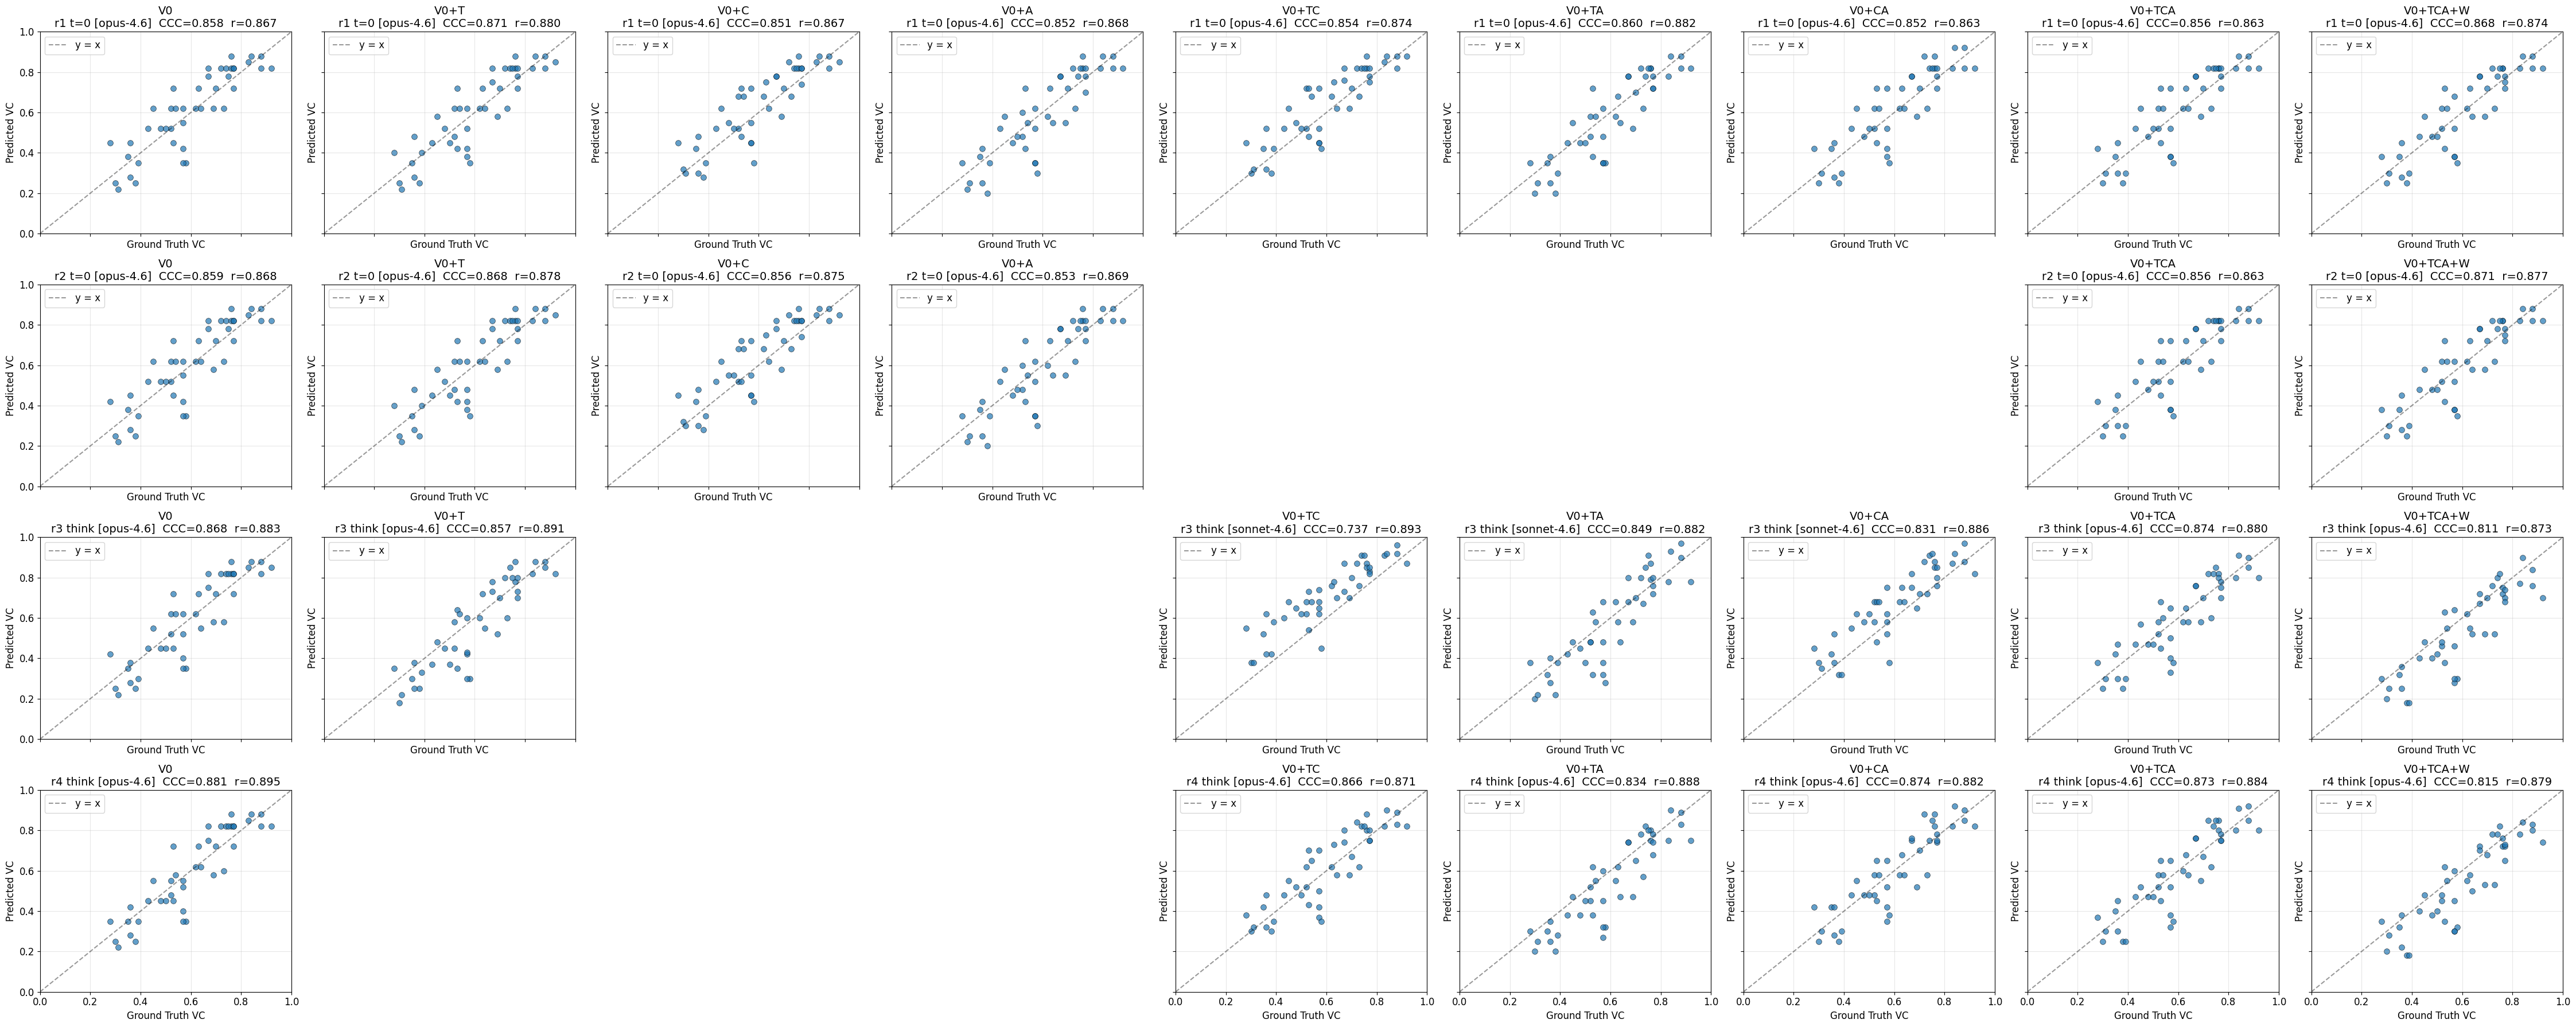

In [68]:
# Scatter plots: one row per run, one column per variant
available_runs = [r for r in RUNS if any(n in merged_by_run[r].columns for n in VARIANT_BASES)]
variants_to_plot = list(VARIANT_BASES.keys())
nrows, ncols = len(available_runs), len(variants_to_plot)

fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4.5 * nrows),
                         sharex=True, sharey=True, squeeze=False)

for row_idx, run in enumerate(available_runs):
    merged = merged_by_run[run]
    for col_idx, name in enumerate(variants_to_plot):
        ax = axes[row_idx][col_idx]
        if name not in merged.columns:
            ax.set_visible(False)
            continue
        sub = merged[['gt', name]].dropna()
        ax.scatter(sub['gt'], sub[name], alpha=0.7, s=50, edgecolor='k', linewidth=0.5)
        ax.plot([0, 1], [0, 1], 'k--', alpha=0.4, label='y = x')

        mode = 't=0' if run in ('r1', 'r2') else 'think'
        model = get_run_model(run, name)
        run_label = f'{run} {mode} [{model}]'

        key = (name, run)
        if key in stats_all.index:
            ccc_val = stats_all.loc[key, 'CCC']
            r_val   = stats_all.loc[key, 'Pearson']
            ax.set_title(f'{name}\n{run_label}  CCC={ccc_val:.3f}  r={r_val:.3f}', fontsize=14)
        else:
            ax.set_title(f'{name}\n{run_label} — no data', fontsize=14)

        ax.set_xlabel('Ground Truth VC', fontsize=12)
        ax.set_ylabel('Predicted VC', fontsize=12)
        ax.tick_params(labelsize=12)
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)
        ax.grid(alpha=0.3)
        ax.legend(loc='upper left', fontsize=12)

plt.tight_layout()
plt.savefig('v0_variants_scatter.png', dpi=200, bbox_inches='tight')
plt.show()
